In [1]:
import json
import shutil
import random
from pathlib import Path
from collections import Counter
import shutil

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
DATASET_ROOT = Path(r"D:\lomba\Telepati 8.0 Datasets")
YOLO_OUT = Path(r"D:\lomba\yolo_out")

FILE_ANOTASI_COCO = "_annotations.coco.json"

SPLITS = ["train", "valid", "test"]

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [3]:
for split in SPLITS:

    split_dir = DATASET_ROOT / split
    json_path = split_dir / FILE_ANOTASI_COCO

    print(f"\n[{split}]")
    print("Folder :", split_dir)
    print("JSON   :", json_path)
    print("JSON exists :", json_path.exists())


[train]
Folder : D:\lomba\Telepati 8.0 Datasets\train
JSON   : D:\lomba\Telepati 8.0 Datasets\train\_annotations.coco.json
JSON exists : True

[valid]
Folder : D:\lomba\Telepati 8.0 Datasets\valid
JSON   : D:\lomba\Telepati 8.0 Datasets\valid\_annotations.coco.json
JSON exists : True

[test]
Folder : D:\lomba\Telepati 8.0 Datasets\test
JSON   : D:\lomba\Telepati 8.0 Datasets\test\_annotations.coco.json
JSON exists : True


In [4]:
def cek_coco(json_path):

    data = json.loads(
        json_path.read_text(encoding="utf-8")
    )

    images = {
        img["id"]: img
        for img in data["images"]
    }

    categories = {
        cat["id"]: cat["name"]
        for cat in data["categories"]
    }

    image_ids = set(images.keys())

    Anotasi_per_image = {}

    for anotasi in data["annotations"]:

        Anotasi_per_image.setdefault(
            anotasi["image_id"], []
        ).append(anotasi)

    gambar_tanpa_anotasi = [
        gambar
        for id_gambar, gambar in images.items()
        if id_gambar not in Anotasi_per_image
    ]

    invalid_bbox = []

    for anotasi in data["annotations"]:

        if anotasi["image_id"] not in images:
            continue

        img = images[anotasi["image_id"]]

        W = img["width"]
        H = img["height"]

        bbox = anotasi.get("bbox")

        if (
            bbox is None
            or len(bbox) != 4
            or bbox[2] <= 0
            or bbox[3] <= 0
        ):
            invalid_bbox.append(anotasi)
            continue

        x, y, w, h = bbox

        if (
            x < 0
            or y < 0
            or x + w > W
            or y + h > H
        ):
            invalid_bbox.append(anotasi)

    class_counts = Counter()

    for anotasi in data["annotations"]:

        nama = categories.get(
            anotasi["category_id"],
            "UNKNOWN"
        )

        class_counts[nama] += 1

    print(f"Gambar              : {len(images)}")
    print(f"Anotasi            : {len(data['annotations'])}")
    print(f"Gambar tanpa anotasi : {len(gambar_tanpa_anotasi)}")
    print(f"Bbox invalid/outside    : {len(invalid_bbox)}")

    print("Distribusi kategori:")

    for name, count in class_counts.most_common():
        print(f"{name:<35}: {count}")

    return data

In [5]:
data_coco= {}

for split in SPLITS:

    json_path = DATASET_ROOT / split / FILE_ANOTASI_COCO
    print(f"AUDIT {split.upper()}")

    data_coco[split] = cek_coco(json_path)

AUDIT TRAIN
Gambar              : 10133
Anotasi            : 20163
Gambar tanpa anotasi : 59
Bbox invalid/outside    : 427
Distribusi kategori:
BrownSpot                          : 3388
Blast                              : 3033
Rice-Tungro                        : 2540
Sheath Blight                      : 1762
Brown spot                         : 1622
Leaf Scald                         : 1224
False-Smut                         : 852
Infected Blast                     : 832
Leaf-roller                        : 812
Healthy Rice Leaf                  : 717
Healthy Rice beads                 : 699
Healthy                            : 686
Bacterial panicle Blight           : 528
Bacterial leaf blight              : 476
Leaf blast                         : 284
healthy                            : 272
Narrow brown                       : 222
Leaf scald                         : 214
AUDIT VALID
Gambar              : 2106
Anotasi            : 4888
Gambar tanpa anotasi : 13
Bbox invalid/outside 

In [6]:
CLASS_MAPPING = {

    "Bacterial leaf blight":
        "bacterial_leaf_blight",

    "Bacterial panicle Blight":
        "bacterial_panicle_blight",

    "Blast":
        "blast",

    "Leaf blast":
        "blast",

    "Infected Blast":
        "blast",

    "Brown spot":
        "brown_spot",

    "BrownSpot":
        "brown_spot",

    "False-Smut":
        "false_smut",

    "Healthy Rice Leaf":
        "healthy",

    "Healthy Rice beads":
        "healthy",

    "Healthy":
        "healthy",

    "healthy":
        "healthy",

    "Leaf-roller":
        "leaf_roller",

    "Leaf Scald":
        "leaf_scald",

    "Leaf scald":
        "leaf_scald",

    "Narrow brown":
        "narrow_brown",

    "Sheath Blight":
        "sheath_blight",

    "Rice-Tungro":
        "tungro",
}

In [7]:
CLASS_NAMES = [
    "bacterial_leaf_blight",
    "bacterial_panicle_blight",
    "blast",
    "brown_spot",
    "false_smut",
    "healthy",
    "leaf_roller",
    "leaf_scald",
    "narrow_brown",
    "sheath_blight",
    "tungro",
]

CLASS_TO_ID = {
    name: i
    for i, name in enumerate(CLASS_NAMES)
}
print(CLASS_TO_ID)

{'bacterial_leaf_blight': 0, 'bacterial_panicle_blight': 1, 'blast': 2, 'brown_spot': 3, 'false_smut': 4, 'healthy': 5, 'leaf_roller': 6, 'leaf_scald': 7, 'narrow_brown': 8, 'sheath_blight': 9, 'tungro': 10}


In [8]:
SPLIT_MAPPING = {
    "train": "train",
    "valid": "val",
    "test": "test",
}
for split in SPLIT_MAPPING.values():

    (YOLO_OUT / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )

    (YOLO_OUT / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )

In [9]:
for split in ["train", "val", "test"]:

    (YOLO_OUT / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )

    (YOLO_OUT / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )

print("Folder YOLO berhasil dibuat.")

Folder YOLO berhasil dibuat.


In [10]:
for split in SPLITS:

    input_dir = DATASET_ROOT / split

    json_path = input_dir / FILE_ANOTASI_COCO

    if split == "valid":
        output_split = "val"
    else:
        output_split = split

    image_out = YOLO_OUT / "images" / output_split
    label_out = YOLO_OUT / "labels" / output_split

    with open(json_path, "r", encoding="utf-8") as f:
        coco = json.load(f)


    images = {
        image["id"]: image
        for image in coco["images"]
    }

    categories = {
        category["id"]: category["name"]
        for category in coco["categories"]
    }


    annotations_per_image = {
        image_id: []
        for image_id in images
    }


    invalid_count = 0
    clipped_count = 0


    for ann in coco["annotations"]:

        image_id = ann["image_id"]

        category_name = categories[ann["category_id"]]

        mapped_class = CLASS_MAPPING.get(category_name)

        if mapped_class is None:
            continue

        class_id = CLASS_TO_ID[mapped_class]


        # COCO bbox
        x, y, w, h = ann["bbox"]

        img_w = images[image_id]["width"]
        img_h = images[image_id]["height"]


        x1 = x
        y1 = y
        x2 = x + w
        y2 = y + h


        new_x1 = max(0, x1)
        new_y1 = max(0, y1)

        new_x2 = min(img_w, x2)
        new_y2 = min(img_h, y2)


        new_w = new_x2 - new_x1
        new_h = new_y2 - new_y1

        if new_w <= 0 or new_h <= 0:

            invalid_count += 1
            continue

        if (
            new_x1 != x1 or
            new_y1 != y1 or
            new_x2 != x2 or
            new_y2 != y2
        ):
            clipped_count += 1

        x_center = (new_x1 + new_x2) / 2 / img_w
        y_center = (new_y1 + new_y2) / 2 / img_h

        width = new_w / img_w
        height = new_h / img_h


        annotations_per_image[image_id].append(
            f"{class_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{width:.6f} "
            f"{height:.6f}"
        )


    for image_id, image_info in images.items():

        file_name = image_info["file_name"]

        source_image = input_dir / file_name

        if not source_image.exists():
            continue


        # Copy image
        shutil.copy2(
            source_image,
            image_out / Path(file_name).name
        )


        # Label
        label_name = Path(file_name).stem + ".txt"

        label_path = label_out / label_name


        with open(label_path, "w") as f:

            for line in annotations_per_image[image_id]:

                f.write(line + "\n")


    print(
        f"{split} selesai | "
        f"clipped: {clipped_count} | "
        f"dibuang: {invalid_count}"
    )

train selesai | clipped: 427 | dibuang: 0
valid selesai | clipped: 34 | dibuang: 0
test selesai | clipped: 24 | dibuang: 0


In [11]:
yaml_text = f"""
path: {YOLO_OUT}

train: images/train
val: images/val
test: images/test

nc: {len(CLASS_NAMES)}

names:
"""

for i, name in enumerate(CLASS_NAMES):
    yaml_text += f"  {i}: {name}\n"


with open(YOLO_OUT / "data.yaml", "w") as f:
    f.write(yaml_text)


print(yaml_text)


path: D:\lomba\yolo_out

train: images/train
val: images/val
test: images/test

nc: 11

names:
  0: bacterial_leaf_blight
  1: bacterial_panicle_blight
  2: blast
  3: brown_spot
  4: false_smut
  5: healthy
  6: leaf_roller
  7: leaf_scald
  8: narrow_brown
  9: sheath_blight
  10: tungro



In [12]:
for split in ["train", "val", "test"]:

    images = list(
        (YOLO_OUT / "images" / split).glob("*")
    )

    labels = list(
        (YOLO_OUT / "labels" / split).glob("*.txt")
    )

    print(
        split,
        "images:", len(images),
        "labels:", len(labels)
    )

train images: 10133 labels: 10133
val images: 2106 labels: 2106
test images: 1059 labels: 1059


In [13]:
label_files = list(
    (YOLO_OUT / "labels" / "train").glob("*.txt")
)

print(label_files[0])
print()

print(label_files[0].read_text())

D:\lomba\yolo_out\labels\train\01-Bacterial-leaf-blight_jpg.rf.24bb7957dc4d31545399a7c4b5d71271.txt

0 0.382176 0.515572 0.286227 0.165519
0 0.151891 0.599936 0.156906 0.115497
0 0.773429 0.766488 0.446858 0.401727



In [18]:
import matplotlib.patches as Rectangle
def visualisasi_sampel(
    output_dir,
    split="train",
    sample_size=20
):

    images_dir = (
        output_dir /
        "images" /
        split
    )

    labels_dir = (
        output_dir /
        "labels" /
        split
    )

    image_files = [
        p for p in images_dir.rglob("*")
        if p.suffix.lower()
        in [".jpg", ".jpeg", ".png"]
    ]

    random.seed(SEED)

    samples = random.sample(
        image_files,
        min(sample_size, len(image_files))
    )

    cols = 3
    rows = int(
        np.ceil(len(samples) / cols)
    )

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(15, 5 * rows)
    )

    axes = np.array(axes).reshape(-1)

    for ax, image_path in zip(
        axes,
        samples
    ):

        image = Image.open(image_path)

        W, H = image.size

        ax.imshow(image)


        label_path = (
            labels_dir /
            image_path.relative_to(images_dir)
        ).with_suffix(".txt")

        # Kalau label tidak ada
        if not label_path.exists():
            ax.set_title(image_path.name)
            ax.axis("off")
            continue

        lines = label_path.read_text(
            encoding="utf-8"
        ).splitlines()


        for line in lines:

            if not line.strip():
                continue

            class_id, xc, yc, w, h = map(
                float,
                line.split()
            )

            class_id = int(class_id)

            # YOLO normalized → pixel
            xc *= W
            yc *= H
            w *= W
            h *= H

            x1 = xc - w / 2
            y1 = yc - h / 2

            rect = Rectangle.Rectangle(
                (x1, y1),
                w,
                h,
                fill=False,
                linewidth=2
            )

            ax.add_patch(rect)

            ax.text(
                x1,
                y1,
                CLASS_NAMES[class_id],
                fontsize=8,
                backgroundcolor="white"
            )

        ax.set_title(
            image_path.name
        )

        ax.axis("off")

    for ax in axes[len(samples):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

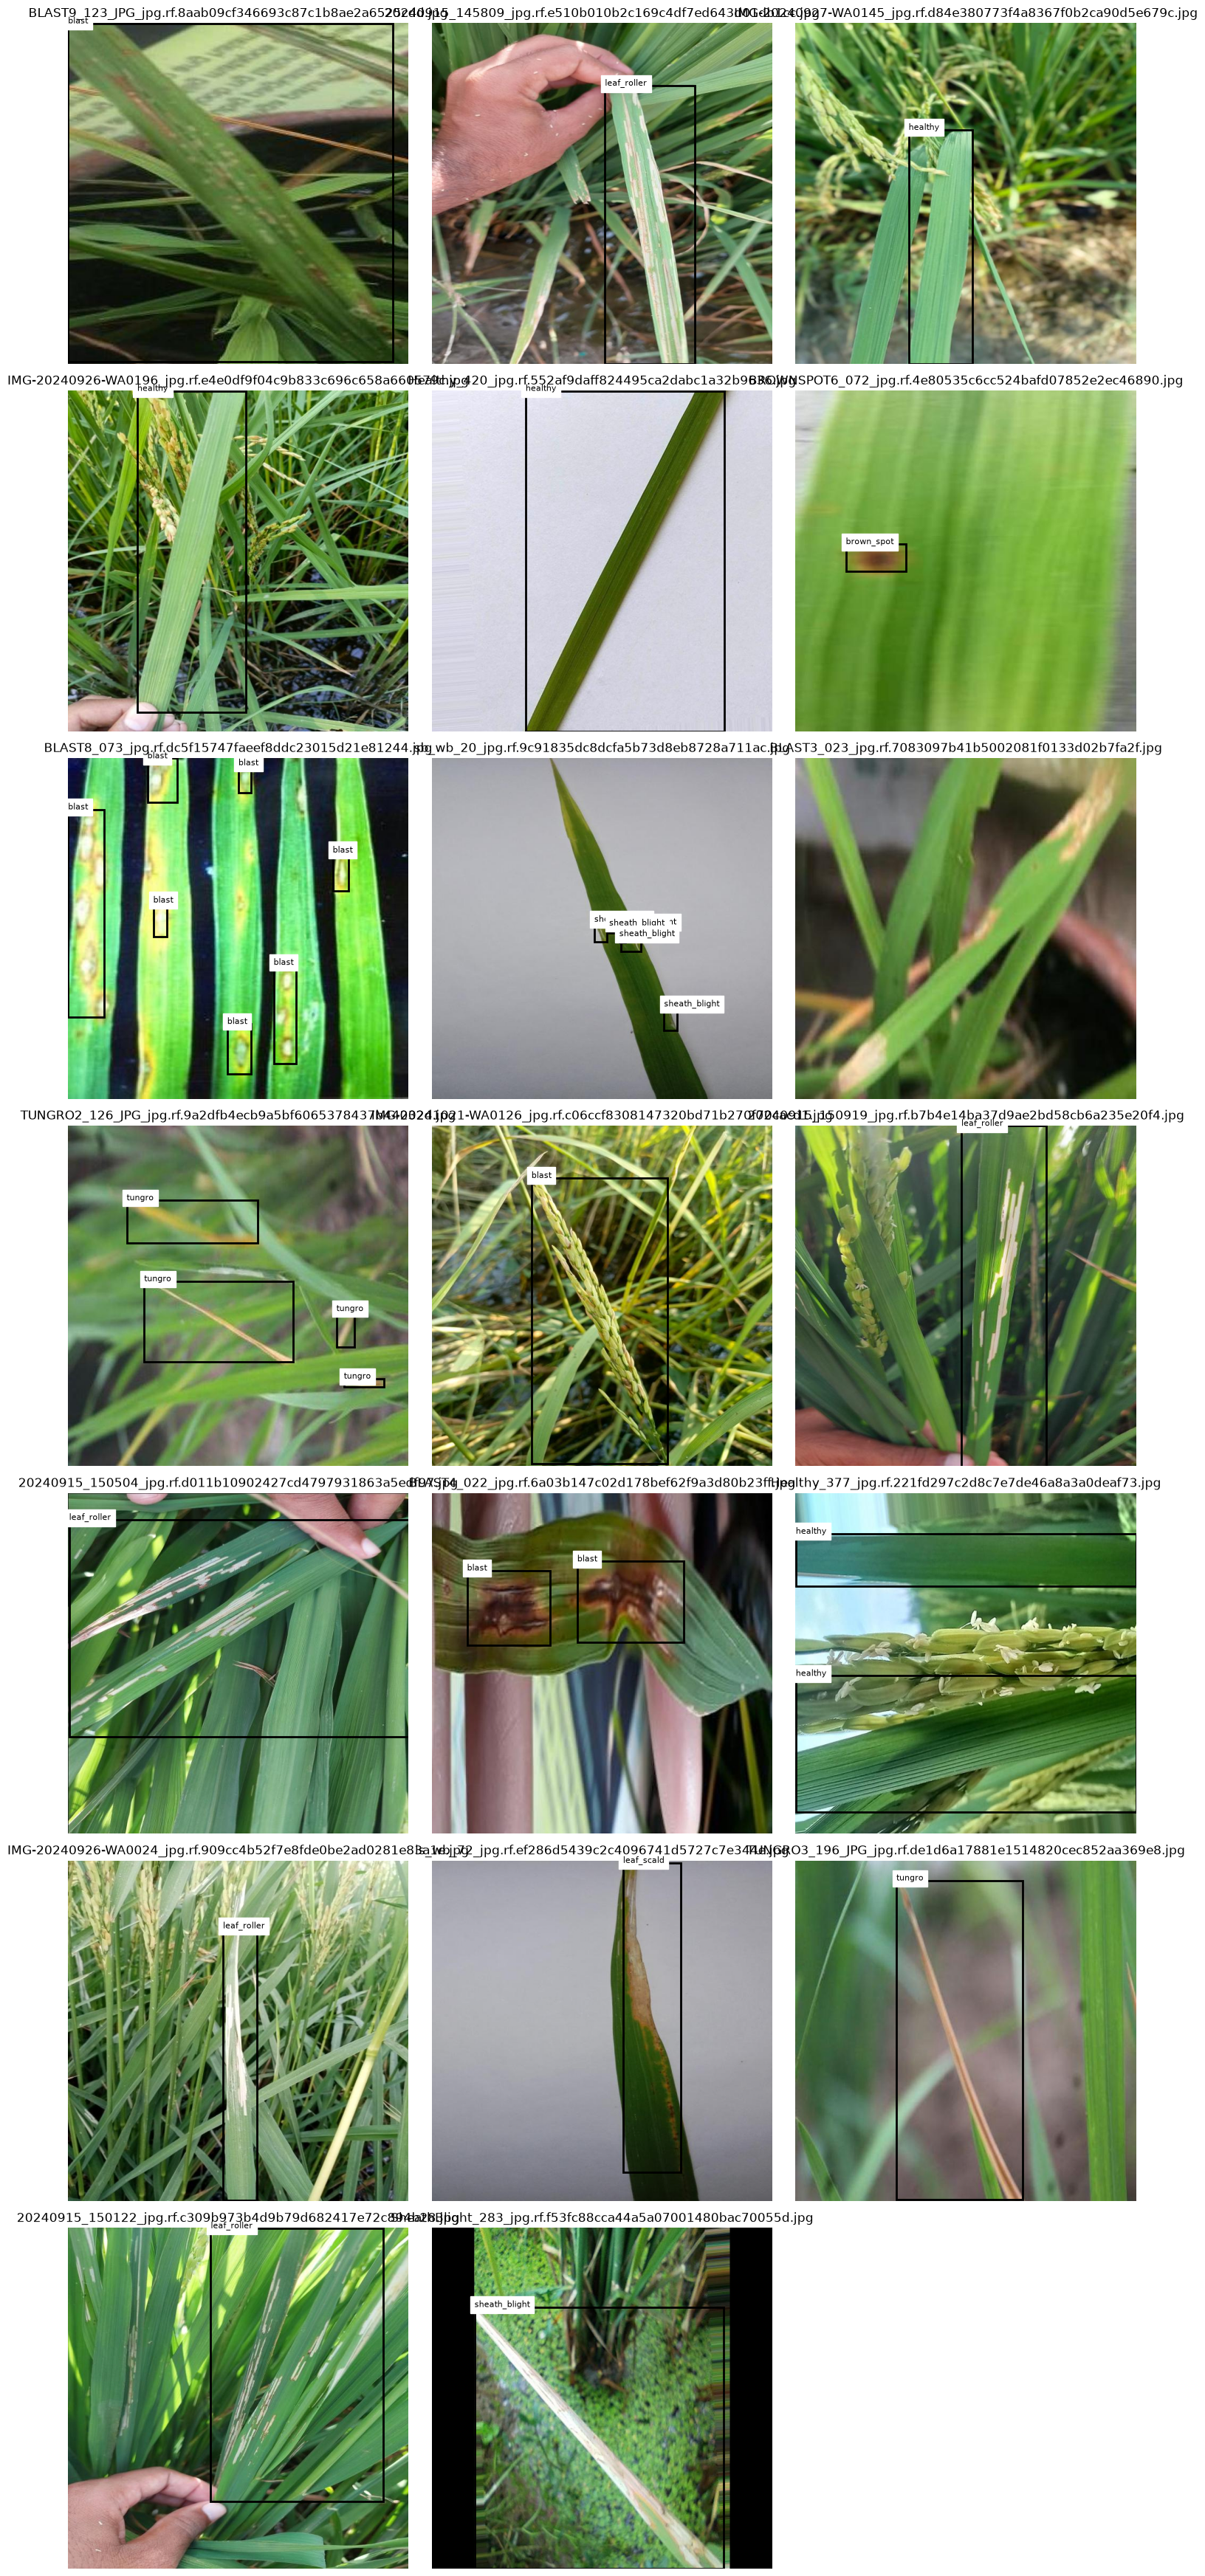

In [19]:
visualisasi_sampel(
    YOLO_OUT,
    split="train",
    sample_size=20
)

In [20]:
import pandas as pd
distribution = {}

for split in ["train", "val", "test"]:

    label_dir = YOLO_OUT / "labels" / split

    counter = Counter()

    for label_path in label_dir.glob("*.txt"):

        lines = label_path.read_text(
            encoding="utf-8"
        ).splitlines()

        for line in lines:

            if not line.strip():
                continue

            class_id = int(line.split()[0])

            counter[class_id] += 1

    distribution[split] = counter

df = pd.DataFrame({
    "class": CLASS_NAMES,

    "train": [
        distribution["train"][i]
        for i in range(len(CLASS_NAMES))
    ],

    "val": [
        distribution["val"][i]
        for i in range(len(CLASS_NAMES))
    ],

    "test": [
        distribution["test"][i]
        for i in range(len(CLASS_NAMES))
    ],
})


df["total"] = (
    df["train"]
    + df["val"]
    + df["test"]
)


df = df.sort_values(
    "total",
    ascending=False
).reset_index(drop=True)


print(df)

                       class  train   val  test  total
0                 brown_spot   5010  1461   840   7311
1                      blast   4149   947   535   5631
2                     tungro   2540   760   411   3711
3                    healthy   2374   424   184   2982
4              sheath_blight   1762   488   269   2519
5                 leaf_scald   1438   390   222   2050
6                 false_smut    852    86    43    981
7                leaf_roller    812    87    44    943
8      bacterial_leaf_blight    476   125    59    660
9   bacterial_panicle_blight    528    45    27    600
10              narrow_brown    222    75    36    333


In [ ]:
from ultralytics import YOLO

model_yolo26s_p2= YOLO("yolo26s-p2.yaml")

results_yolo26s_p2= model_yolo26s_p2.train(
    data=str(YOLO_OUT / "data.yaml"),

    epochs=200,
    batch=32,
    imgsz=1024,
    patience=30,
    save_period=20,
    

    pretrained=False,
    seed=SEED,

    project="/training_output",
    name="train_yolo_26s-p2",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.155 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.154  Python-3.12.13 torch-2.14.0+cpu CPU (AMD Ryzen 3 5300U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\lomba\yolo_out\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, m

In [ ]:
best_model= YOLO("/training_output/train_yolo_26s-p2/weights/best.pt")

In [ ]:
metrics = best_model.val(
    data=str(YOLO_OUT / "data.yaml"),
    split="val",
    imgsz=1024
)

In [ ]:
final_metrics = best_model.val(
    data=str(YOLO_OUT/"data.yaml"),
    split="test",
    imgsz=1024
)

print(
    "Test mAP50 :",
    final_metrics.box.map50
)

print(
    "Test mAP50-95 :",
    final_metrics.box.map
)

test_precision = final_metrics.box.mp
test_recall = final_metrics.box.mr

if test_precision + test_recall > 0:

    test_f1 = (
        2 * test_precision * test_recall
        / (test_precision + test_recall)
    )

else:
    test_f1 = 0

print(
    "Test Precision :",
    test_precision
)

print(
    "Test Recall    :",
    test_recall
)

print(
    "Test F1-score  :",
    test_f1
)